# Tugas 1 - Klasifikasi Wine Quality dengan KNN
  
| Nama              | NRP        |
|-------------------|------------|
|Jordan Sebastian Simatupang              |5054251038       |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Wine Quality Dataset. Dataset bisa diakses melalui link berikut:\
🔗 https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

Tujuan utama dari tugas ini adalah membangun model K-Nearest Neighbors (KNN) untuk mengklasifikasikan kualitas wine. 

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset & Eksplorasi Awal

- Memuat dataset, melihat struktur data, dan distribusi label.

2. Preprocessing 
- Memproses data agar siap untuk digunakan dalam membangun model.

3. Eksperimen Model KNN
- Bangun model KNN dengan mencoba beberapa nilai k (misalnya 3, 5, dan 7 --> BEBAS) serta dua metric jarak (seperti Euclidean dan Manhattan).
- Eksperimen ini bertujuan untuk membandingkan performa KNN dengan parameter yang berbeda.

4. Evaluasi Model
- Hitung metrik evaluasi seperti Accuracy, Precision, Recall, F1-Score, serta visualisasikan Confusion Matrix.

5. Analisis & Kesimpulan
- Bandingkan hasil antar eksperimen yang telah dilakukan dan berikan kesimpulan.


# 1. Persiapan Dataset & Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
#  Load Dataset dan menampilkan informasi dasar tentang dataset, seperti jumlah baris dan kolom, tipe data, jumlah nilai yang hilang, dan informasi lainnya yang dibutuhkan.

'''

data = pd.read_csv('namafile.csv')
data.head()
data.info()
data.describe()

! Cari fungsi-fungsi yang dapat digunakan untuk menampilkan informasi yang diinginkan. 

'''
data = pd.read_csv('WineQT.csv')
data.head()
data.info()
print("Jumlah duplikat:", data.duplicated().sum())
display(data.describe().T)
print("Ukuran dataset:", data.shape)
print(data["quality"].value_counts().sort_index())

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB
Jumlah duplikat: 0


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


Ukuran dataset: (1143, 13)
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


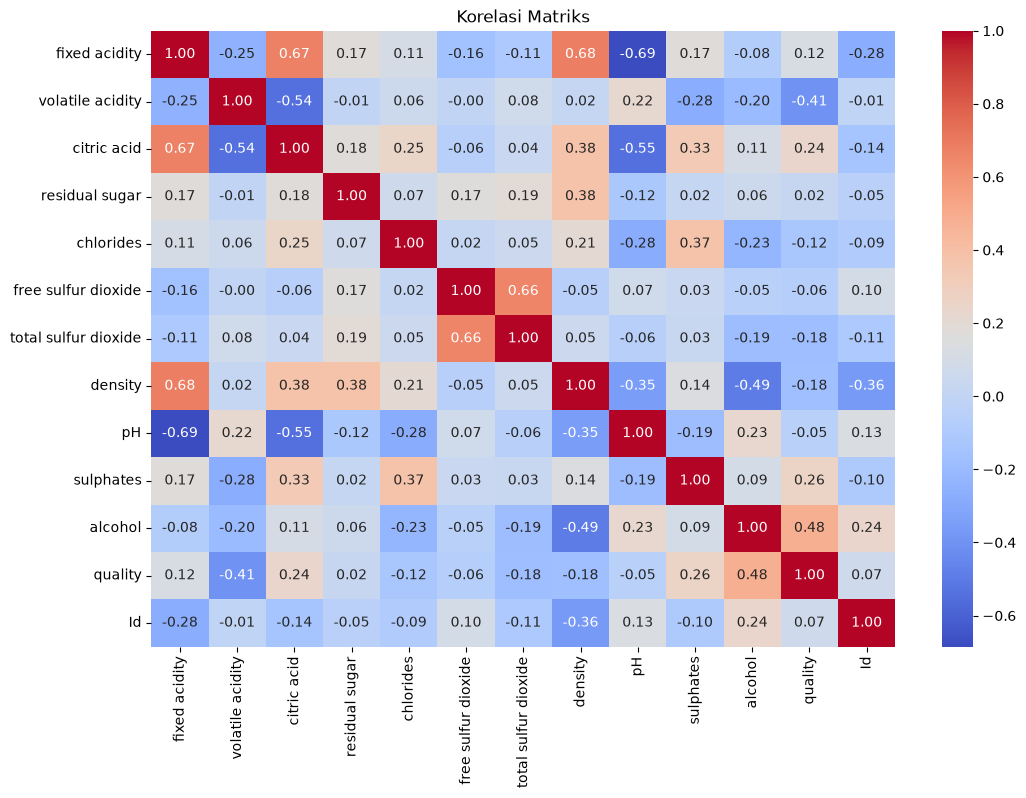

In [3]:
# Tampilkan Korelasi Matrix
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korelasi Matriks")
plt.show()

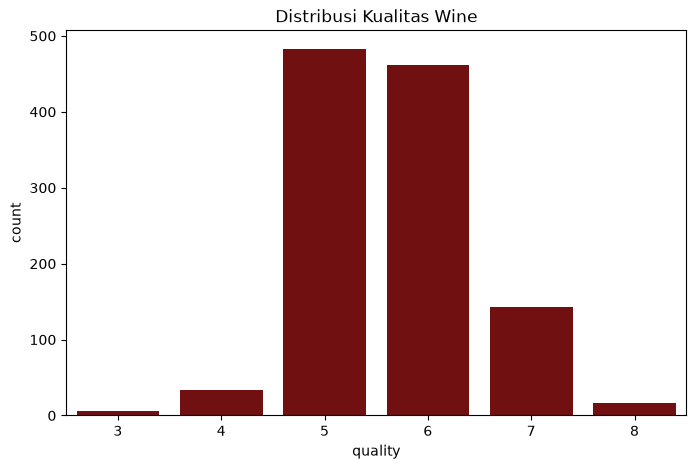

In [4]:
# Tampilkan distribusi label (quality) dalam bentuk visualisasi, misalnya menggunakan histogram atau bar plot.
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x="quality", color="maroon")
plt.title("Distribusi Kualitas Wine")
plt.show()

## Silahkan Lakukan Exploratory Data Analysis (EDA) tambahan yang dibutuhkan. 

# 2. Preprocessing




In [5]:
# NaN handling (drop, impute, etc.), duplicate handling, dan lain-lain.
df = pd.DataFrame(data)
X = df.drop(columns=['quality', 'Id'], errors='ignore')
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Ukuran X_train : {X_train_scaled.shape}")
print(f"Ukuran X_test  : {X_test_scaled.shape}")
print("Missing value sebelum penanganan:")
print(data.isnull().sum().sum())
print("Jumlah duplikat sebelum penanganan:", data.duplicated().sum())
print("Ukuran dataset sebelum preprocessing:", data.shape)
print("\n")

numeric_columns = data.select_dtypes(include=np.number).columns
data[numeric_columns] = data[numeric_columns].fillna(data[numeric_columns].median())
data = data.drop_duplicates().reset_index(drop=True)

print("Missing value setelah penanganan:")
print(data.isnull().sum().sum())
print("Jumlah duplikat setelah penanganan:", data.duplicated().sum())
print("Ukuran dataset setelah preprocessing:", data.shape)

Ukuran X_train : (914, 11)
Ukuran X_test  : (229, 11)
Missing value sebelum penanganan:
0
Jumlah duplikat sebelum penanganan: 0
Ukuran dataset sebelum preprocessing: (1143, 13)


Missing value setelah penanganan:
0
Jumlah duplikat setelah penanganan: 0
Ukuran dataset setelah preprocessing: (1143, 13)


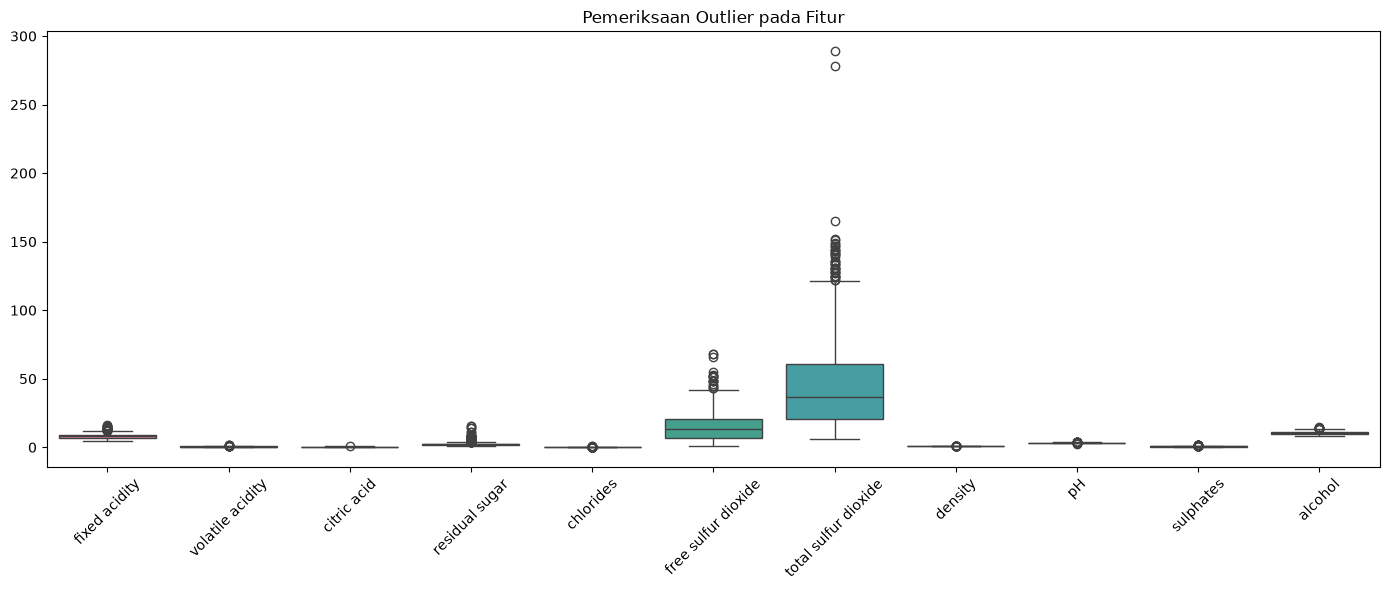

In [6]:
# Periksa Outliers (jika diperlukan), misalnya menggunakan boxplot atau metode statistik lainnya. (Bisa dilakukan eksperimen dengan dan tanpa outlier untuk melihat perbedaan performa model)
feature_columns = data.drop(columns=["quality", "Id"]).columns

plt.figure(figsize=(14, 6))
sns.boxplot(data=data[feature_columns])
plt.xticks(rotation=45)
plt.title("Pemeriksaan Outlier pada Fitur")
plt.tight_layout()
plt.show()

In [7]:
# Scaling data (jika diperlukan), misalnya menggunakan StandardScaler atau MinMaxScaler. (Bisa dilakukan eksperimen dengan dan tanpa scaling untuk melihat perbedaan performa model)
# Perhatikan data leakage saat melakukan scaling. Scaling harus dilakukan setelah membagi data menjadi train dan test set.
X = data.drop(columns=["quality", "Id"])
y = data["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
 )

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Ukuran X_train:", X_train_scaled.shape)
print("Ukuran X_test:", X_test_scaled.shape)
print("Rata-rata fitur train setelah scaling:")
print(np.round(X_train_scaled.mean(axis=0), 2))
print("Standar deviasi fitur train setelah scaling:")
print(np.round(X_train_scaled.std(axis=0), 2))

Ukuran X_train: (914, 11)
Ukuran X_test: (229, 11)
Rata-rata fitur train setelah scaling:
[ 0. -0.  0.  0.  0.  0. -0.  0. -0.  0. -0.]
Standar deviasi fitur train setelah scaling:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


# 3. Eksperimen Model KNN


In [8]:
# Split data menjadi train dan test set. (misal 80% train, 20% test)
# Gunakan fungsi train_test_split dari sklearn.model_selection untuk membagi data menjadi train dan test set. Pastikan untuk memisahkan fitur (X) dan label (y) sebelum melakukan split.
# Gunakan stratify=y agar distribusi label pada train dan test set tetap sama dengan distribusi label pada dataset asli.
# Train model KNN menggunakan train set. Gunakan fungsi KNeighborsClassifier dari sklearn.neighbors untuk membuat model KNN. Lakukan eksperimen dengan berbagai nilai k (misal k=1, 3, 5, 7, 9) dan catat performa model pada train set dan test set.
k_values = [1, 3, 5, 7, 9]
distance_metrics = ["euclidean", "manhattan"]
results = []

for metric in distance_metrics:
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
        knn.fit(X_train_scaled, y_train)

        train_predictions = knn.predict(X_train_scaled)
        test_predictions = knn.predict(X_test_scaled)

        results.append({
            "metric": metric,
            "k": k,
            "train_accuracy": accuracy_score(y_train, train_predictions),
            "test_accuracy": accuracy_score(y_test, test_predictions),
            "test_precision": precision_score(y_test, test_predictions, average="weighted", zero_division=0),
            "test_recall": recall_score(y_test, test_predictions, average="weighted", zero_division=0),
            "test_f1": f1_score(y_test, test_predictions, average="weighted", zero_division=0)
        })

results_df = pd.DataFrame(results).sort_values("test_f1", ascending=False).reset_index(drop=True)
results_df.round(4)

,metric,k,train_accuracy,test_accuracy,test_precision,test_recall,test_f1
0,manhattan,1,1.0000,0.6594,0.6446,0.6594,0.6517
1,euclidean,1,1.0000,0.6507,0.6334,0.6507,0.6412
2,manhattan,9,0.6477,0.6594,0.6222,0.6594,0.6390
3,euclidean,9,0.6400,0.6201,0.5877,0.6201,0.6013
4,euclidean,3,0.7593,0.6070,0.5997,0.6070,0.6000
5,manhattan,7,0.6641,0.6114,0.5781,0.6114,0.5939
6,euclidean,7,0.6630,0.5939,0.5687,0.5939,0.5795
7,manhattan,5,0.6915,0.5852,0.5551,0.5852,0.5676
8,euclidean,5,0.6838,0.5764,0.5532,0.5764,0.5632
9,manhattan,3,0.7462,0.5677,0.5621,0.5677,0.5598


# 4. Evaluasi Model


Model terbaik: metric=manhattan, k=1

Classification report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.73      0.74      0.73        97
           6       0.64      0.67      0.66        92
           7       0.63      0.59      0.61        29
           8       0.00      0.00      0.00         3

    accuracy                           0.66       229
   macro avg       0.33      0.33      0.33       229
weighted avg       0.64      0.66      0.65       229



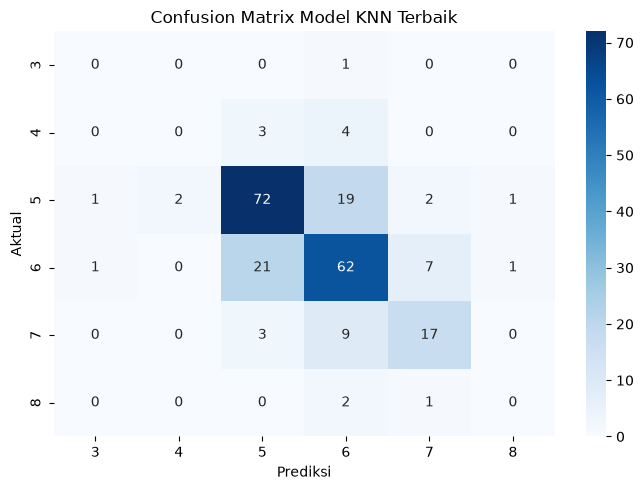

In [9]:
# Tampilkan evaluasi model KNN dengan metriks evaluasi yang sesuai dengan tipe masalah klasifikasi
best_result = results_df.iloc[0]
best_model = KNeighborsClassifier(
    n_neighbors=int(best_result["k"]),
    metric=best_result["metric"]
)
best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)

print(f"Model terbaik: metric={best_result['metric']}, k={int(best_result['k'])}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))

labels = sorted(y.unique())
confusion = confusion_matrix(y_test, y_pred, labels=labels)
plt.figure(figsize=(7, 5))
sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix Model KNN Terbaik")
plt.tight_layout()
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen model KNN yang telah dilakukan. Bandingkan hasil antar eksperimen yang telah dilakukan. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.

### Analisis Hasil Eksperimen


Eksperimen dilakukan menggunakan lima nilai **k** (**1, 3, 5, 7, 9**) dan dua metrik jarak, yaitu Euclidean dan Manhattan. Seluruh fitur distandardisasi terlebih dahulu agar fitur dengan skala besar tidak mendominasi perhitungan jarak.


Berdasarkan weighted F1-score pada data test, model terbaik adalah KNN dengan metrik jarak Manhattan dan **k=1**, dengan accuracy sebesar **0.6594**, precision sebesar **0.6446**, recall sebesar **0.6594**, dan F1-score sebesar **0.6517**. Model dengan Manhattan secara umum memberikan hasil lebih baik daripada Euclidean pada eksperimen ini. Namun, hasil **k=1** pada data train mencapai accuracy **1.0000**, sedangkan accuracy test hanya **0.6594**. Perbedaan ini menunjukkan bahwa model sangat cocok terhadap data train dan berpotensi mengalami overfitting.


Untuk *******k** yang lebih besar, model menjadi lebih sederhana. Pada metrik Manhattan, accuracy test untuk **k=3**, **k=5**, **k=7**, dan **k=9** berturut-turut adalah **0.5677**, **0.5852**, **0.6114**, dan **0.6594**. Pada metrik Euclidean, accuracy test berturut-turut adalah **0.6070**, **0.5764**, **0.5939**, dan **0.6201**. Pada pembagian data ini, **k=9** dengan Manhattan memiliki F1-score yang cukup dekat dengan **k=1**, tetapi gap antara accuracy train dan test jauh lebih kecil sehingga lebih stabil.


Dari confusion matrix, kelas kualitas 5 dan 6 paling banyak dikenali karena jumlah datanya paling besar. Sebaliknya, kelas 3, 4, dan 8 sering salah diklasifikasikan atau tidak berhasil dikenali karena jumlah sampelnya sangat sedikit. Oleh karena itu, weighted average terlihat cukup baik, tetapi macro average hanya sekitar **0.33**, yang menunjukkan performa antar kelas belum seimbang.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

### Kesimpulan dan Saran


Model KNN berhasil digunakan untuk mengklasifikasikan kualitas wine setelah data dibersihkan, dibagi secara stratified, dan distandardisasi. Dari seluruh eksperimen, kombinasi metrik Manhattan dengan **k=1** menghasilkan weighted F1-score test tertinggi, yaitu **0.6517**, dengan accuracy sebesar **0.6594**. Meskipun demikian, hasil ini belum seimbang untuk semua kelas karena dataset didominasi oleh kualitas 5 dan 6.


Untuk eksperimen berikutnya, model dapat ditingkatkan dengan melakukan cross-validation untuk memilih **k** yang lebih representatif, menangani ketidakseimbangan kelas, mencoba pembobotan tetangga (**weights="distance"**), serta membandingkan KNN dengan model lain seperti Random Forest, SVM, atau Gradient Boosting. Evaluasi sebaiknya juga menekankan macro F1-score agar performa pada kelas minoritas tidak tertutupi oleh kelas mayoritas.